## Imports

In [1]:
import pandas as pd
import seaborn as sns
import json

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib as mpl

## Load scores and plotting metadata

In [2]:
df = pd.read_csv("/home/jovyan/pert-bench-fusion-paper/results/scores/sciplex_deg.csv", index_col=0)

In [3]:
with open("/home/jovyan/pert-bench-fusion-paper/results/metadata/fig_index.json", "r") as f:
    fig_index = json.load(f)
method_map = fig_index["sciplex_deg"]
model_type_palette = fig_index['drugs_model_type_palette']
hue_order = fig_index['drugs_hue_order']
mpl.rcParams.update(fig_index["mpl_params"])
mpl.rcParams.update({"legend.loc": "upper right"})

## Split by cell line

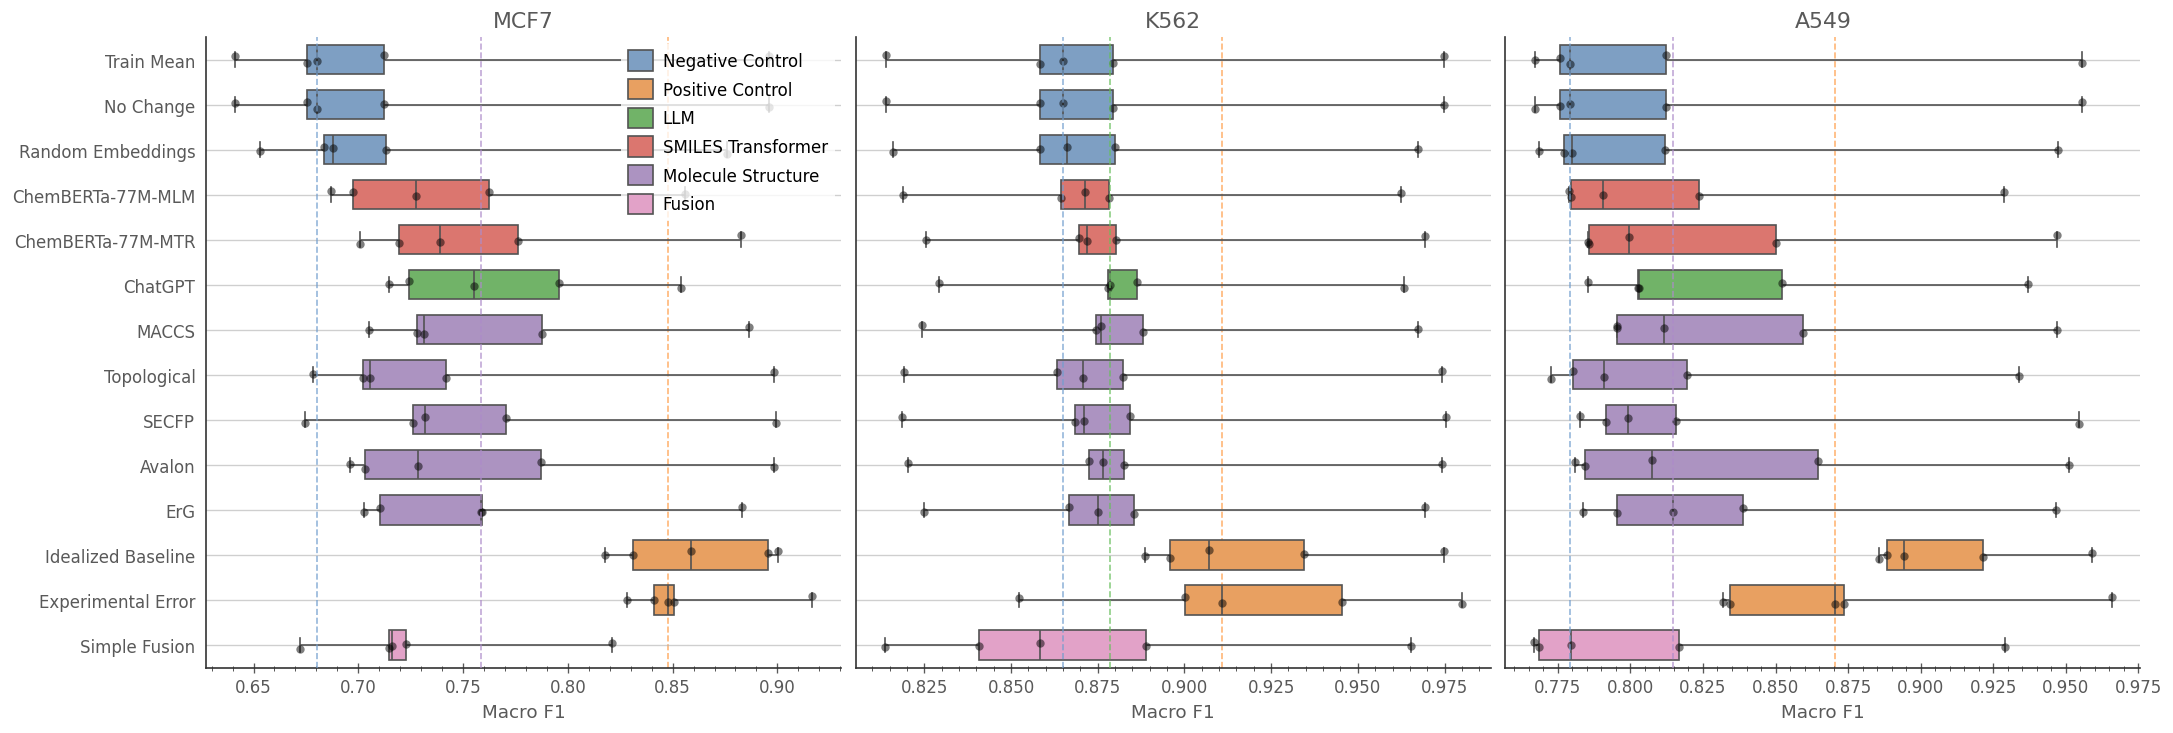

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
for i, cell_line in enumerate(['MCF7', 'K562', 'A549']):

    # Build the cell-line specific dataframe
    idx = (df["cell_line"] == cell_line) & df["name"].isin(method_map)
    df_subset = df[idx].copy()
    df_subset["Model type"] = df_subset["name"].apply(lambda x: method_map[x][1])
    df_subset["name"] = df_subset["name"].apply(lambda x: method_map[x][0])

    present_hues = [
        h for h in hue_order
        if h in df_subset["Model type"].unique()
    ]
    
    # Boxplot
    g = sns.boxplot(
        data=df_subset,
        y="name",
        order=[name for name, _ in method_map.values()],
        hue="Model type",
        hue_order=present_hues,
        x="f1_score",
        ax=axes[i],
        whis=(0, 100),
        width=0.65,
        palette=model_type_palette,
    )

    # Overlay stripplot
    sns.stripplot(
        data=df_subset,
        y="name",
        order=[name for name, _ in method_map.values()],
        color="black",
        alpha=0.5,
        s=5,
        x="f1_score",
        ax=axes[i],
    )

    # Decorate
    g.grid(axis="y")
    g.set(ylabel=None, title=cell_line)
    g.set_xlabel('Macro F1')
    g.legend(title=None)
    if i > 0:
        g.set(yticklabels=[])
        g.legend().remove()

    # Get the best performing model
    best_mask = (
        (df_subset["Model type"] != "Positive Control") &
        (df_subset["Model type"] != "Fusion")
    )
    best_group = (
        df_subset.loc[best_mask]
        .groupby("name")["f1_score"]
        .median()
    )
    best_name = best_group.idxmax()
    best_level = best_group.loc[best_name]
    best_model_type = (
        df_subset.loc[df_subset["name"] == best_name, "Model type"]
        .iloc[0]
    )

    # Draw vertical lines
    g.axvline(
        df_subset[df_subset["name"] == "Train Mean"]["f1_score"].median(),
        color=model_type_palette["Negative Control"],
        linestyle="--",
        linewidth=1,
        zorder=99,
        alpha=0.75,
    )
    g.axvline(
        df_subset[
            df_subset["name"] == f"Experimental Error"
        ]["f1_score"].median(),
        color=model_type_palette["Positive Control"],
        linestyle="--",
        linewidth=1,
        zorder=-99,
        alpha=0.75,
    )
    g.axvline(
        best_level,
        color=model_type_palette[best_model_type],
        linestyle="--",
        linewidth=1,
        zorder=99,
        alpha=0.75,
    )
plt.savefig("fig_A10.pdf")